# Laboratory 2: Making a Dark Image Bright!

## Overview
In this project, we are taking a very dark image (one where you can't see much) and making it bright and clear. 

Think of it like turning on a light in a dark room! We do this in two big steps:
1. **Stretching the Colors:** We take the colors in the picture and stretch them so they use the full range from dark to light. This makes the contrast better.
2. **The Magic Brightness Formula:** We use a special trick called "Gamma Correction." It's like a slider that helps us see into the dark parts of the picture without making everything else look weird.

## Topics Used
- **Image Loading:** How a computer "reads" a file.
- **Normalization:** Stretching colors to make them look better.
- **Gamma Correction:** A sneaky way to change brightness.
- **Displaying Results:** Putting pictures side-by-side to see the difference.

In [1]:
# First, we need to bring in the tools we need for working with images.
import cv2  # This is the main image tool (OpenCV)
import numpy as np  # This helps with math
import matplotlib.pyplot as plt  # This helps us show the pictures

In [2]:
# Now, we tell the computer to open the dark picture file.
# We use '0' to say we want it in black and white (grayscale).
img = cv2.imread('car-transformed-(1).png', 0)

# If the image didn't open correctly, we print an error.
if img is None:
  print("Error: Could not find the image!")

In [3]:
# This step stretches the colors so they go all the way from 0 (black) to 255 (white).
# It makes the picture look a little more defined.
better_contrast = cv2.normalize(img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

In [4]:
# This is the 'Magic Brightness' part (Gamma Correction).
# We pick a number (gamma) to decide how much to brighten it.
gamma = 0.4
invGamma = 1.0 / gamma

# We build a 'lookup table' which is like a list of instructions 
# telling the computer exactly how to change every single dot in the picture.
magic_table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

# Finally, we apply that magic list to our picture to get the final result.
final_pic = cv2.LUT(better_contrast, magic_table)

In [5]:
# We save the new, bright picture to a new file so we don't lose it.
output_path = 'car_transformed.png'
cv2.imwrite(output_path, final_pic)

True

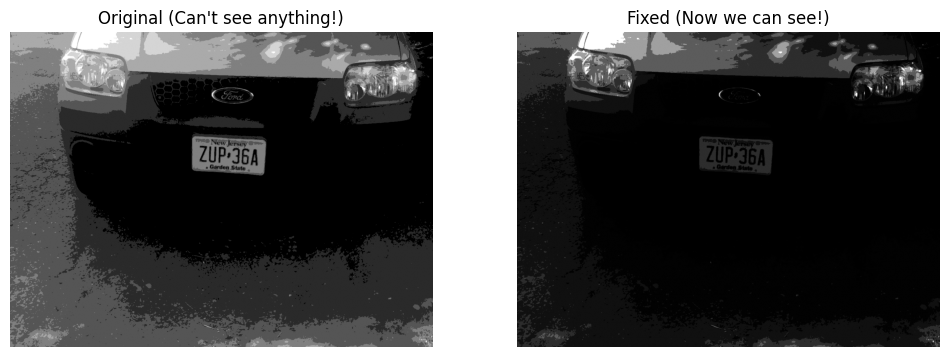

In [6]:
# Finally, we show both pictures side-by-side to prove how much better it looks!
plt.figure(figsize=(12, 6))

# Show the original, dark image on the left.
plt.subplot(1, 2, 1)
plt.title("Original (Can't see anything!)")
plt.imshow(img, cmap='gray')
plt.axis('off')

# Show the fixed, bright image on the right.
plt.subplot(1, 2, 2)
plt.title("Fixed (Now we can see!)")
plt.imshow(final_pic, cmap='gray')
plt.axis('off')

plt.show()